K-means: clustering (agrupamento)  aprendizado não supervisionado, ou seja, dados sem classificação, que procura K grupos de afinidade no conjunto de dados

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
%matplotlib inline


Iris Flower DATASET: https://www.kaggle.com/arshid/iris-flower-dataset

In [4]:
df = pd.read_csv('/content/iris.csv')

In [5]:
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


Mudando o nome da coluna species para target

In [6]:
df.rename(columns={'Species': 'y'}, inplace=True) # inplace = True não cria novo dataframe, altera o atual
db = df.copy() # mantenho db como cópia de df completo
df


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,y
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [8]:
from sklearn import preprocessing
encoder = preprocessing.LabelEncoder()

df['ycat'] = encoder.fit_transform(df['y'])

print(encoder.classes_)

df.head(52)

['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,y,ycat
0,1,5.1,3.5,1.4,0.2,Iris-setosa,0
1,2,4.9,3.0,1.4,0.2,Iris-setosa,0
2,3,4.7,3.2,1.3,0.2,Iris-setosa,0
3,4,4.6,3.1,1.5,0.2,Iris-setosa,0
4,5,5.0,3.6,1.4,0.2,Iris-setosa,0
5,6,5.4,3.9,1.7,0.4,Iris-setosa,0
6,7,4.6,3.4,1.4,0.3,Iris-setosa,0
7,8,5.0,3.4,1.5,0.2,Iris-setosa,0
8,9,4.4,2.9,1.4,0.2,Iris-setosa,0
9,10,4.9,3.1,1.5,0.1,Iris-setosa,0


Remover do dataframe a coluna target, pois já contém a classificação. A ideia é rodar o k-means para ele fazer o agrupamento e comparar com a classificação já existente. Vamos criar um array para as features X

In [11]:
columns_to_drop = ['y', 'ycat']
df.drop(columns_to_drop, inplace=True)


In [14]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'], dtype='object')

In [17]:
df['Id']

,Id
0,1
1,2
2,3
3,4
4,5
...,...
145,146
146,147
147,148
148,149


In [18]:
columns_to_drop = ['Id']
df.drop(columns_to_drop, axis=1, inplace=True)

In [19]:
print(type(df))
X = np.array(df)
print(type(X))
# cria array numpy a partir do dataframe, removendo a coluna 'target'. axis = 1 informa que target é coluna e não linha

<class 'pandas.core.frame.DataFrame'>
<class 'numpy.ndarray'>


In [21]:
#X

Importar KMeans, da lib scikt-Learn

In [22]:
from sklearn.cluster import KMeans

In [23]:
kmeans = KMeans(n_clusters=3, random_state=10) # random state = 0 permite a reprodutibilidade dos testes a cada execução

Treinar o algoritmo KMeans, com o dataset

In [24]:
kmeans.fit(X)

KMeans(n_clusters=3, random_state=10)

In [26]:
df['yhat'] = kmeans.labels_

Visualizar os grupos identificados com labels_

Comparar as classes identificadas com as existentes no DF original. Vamos criar uma coluna adicional no dataframe

In [31]:
df['y'] = db['y']

In [29]:
df

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,yhat,y
0,5.1,3.5,1.4,0.2,1,Iris-setosa
1,4.9,3.0,1.4,0.2,1,Iris-setosa
2,4.7,3.2,1.3,0.2,1,Iris-setosa
3,4.6,3.1,1.5,0.2,1,Iris-setosa
4,5.0,3.6,1.4,0.2,1,Iris-setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,0,Iris-virginica
146,6.3,2.5,5.0,1.9,2,Iris-virginica
147,6.5,3.0,5.2,2.0,0,Iris-virginica
148,6.2,3.4,5.4,2.3,0,Iris-virginica


Exibindo a dispersão original e a encontrada, com a identificação das classes

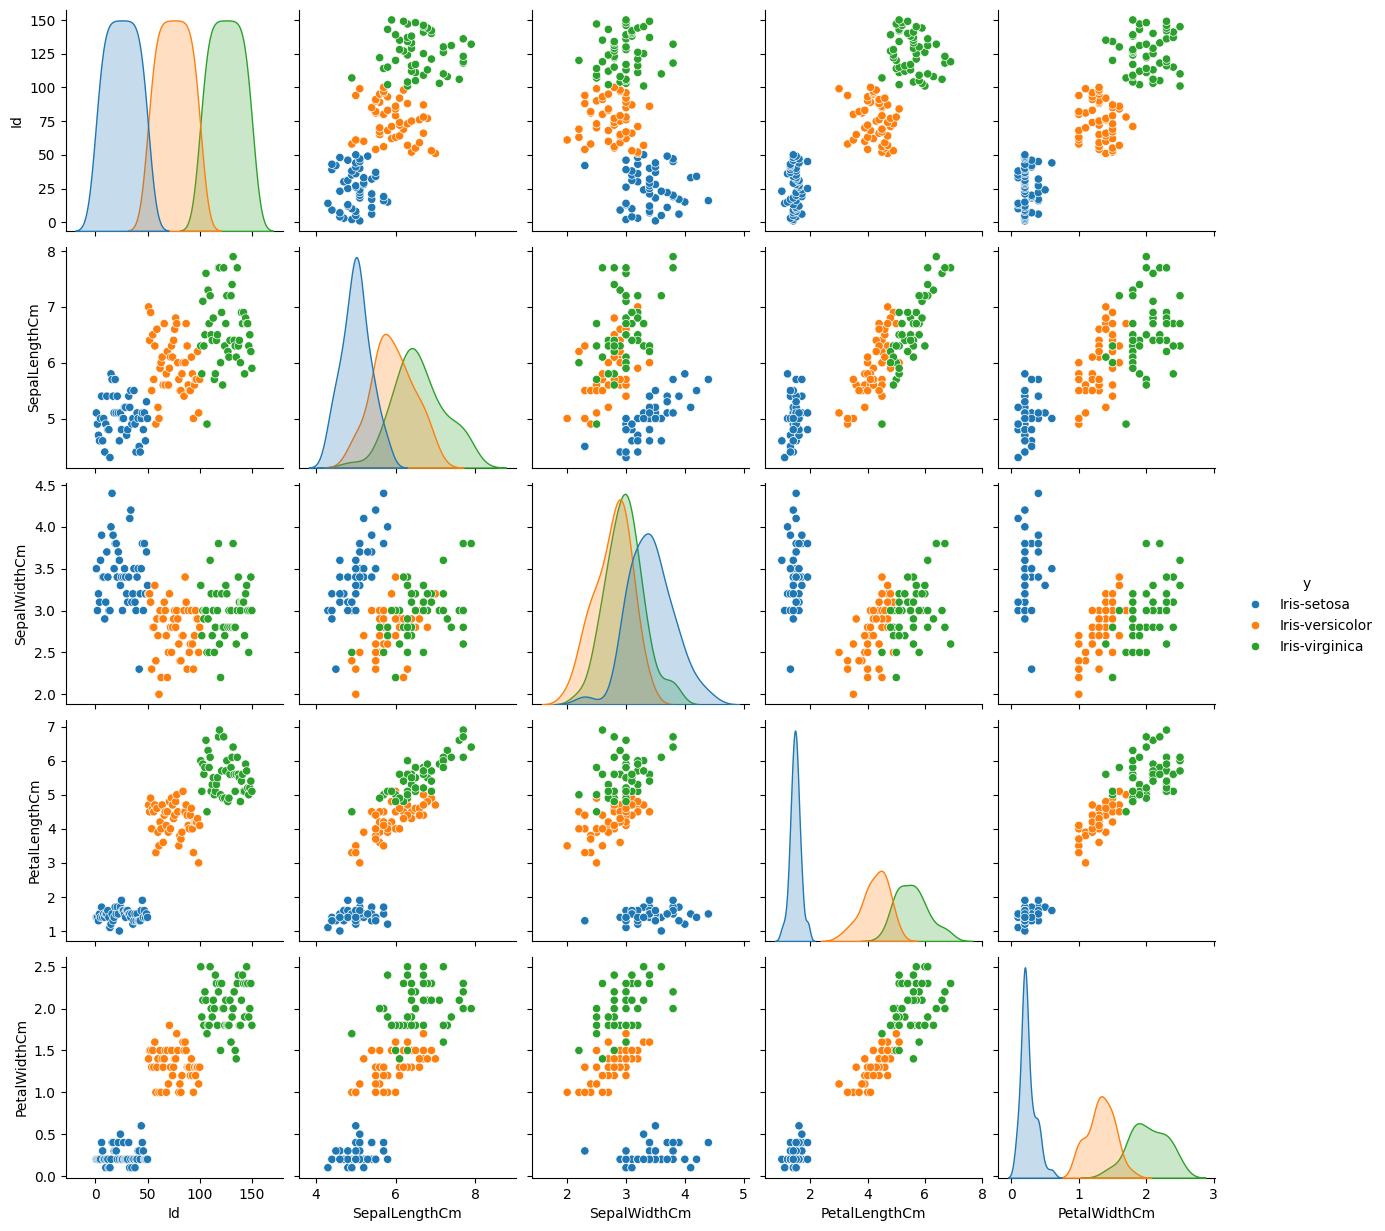

In [32]:
sb.pairplot(db, hue='y')

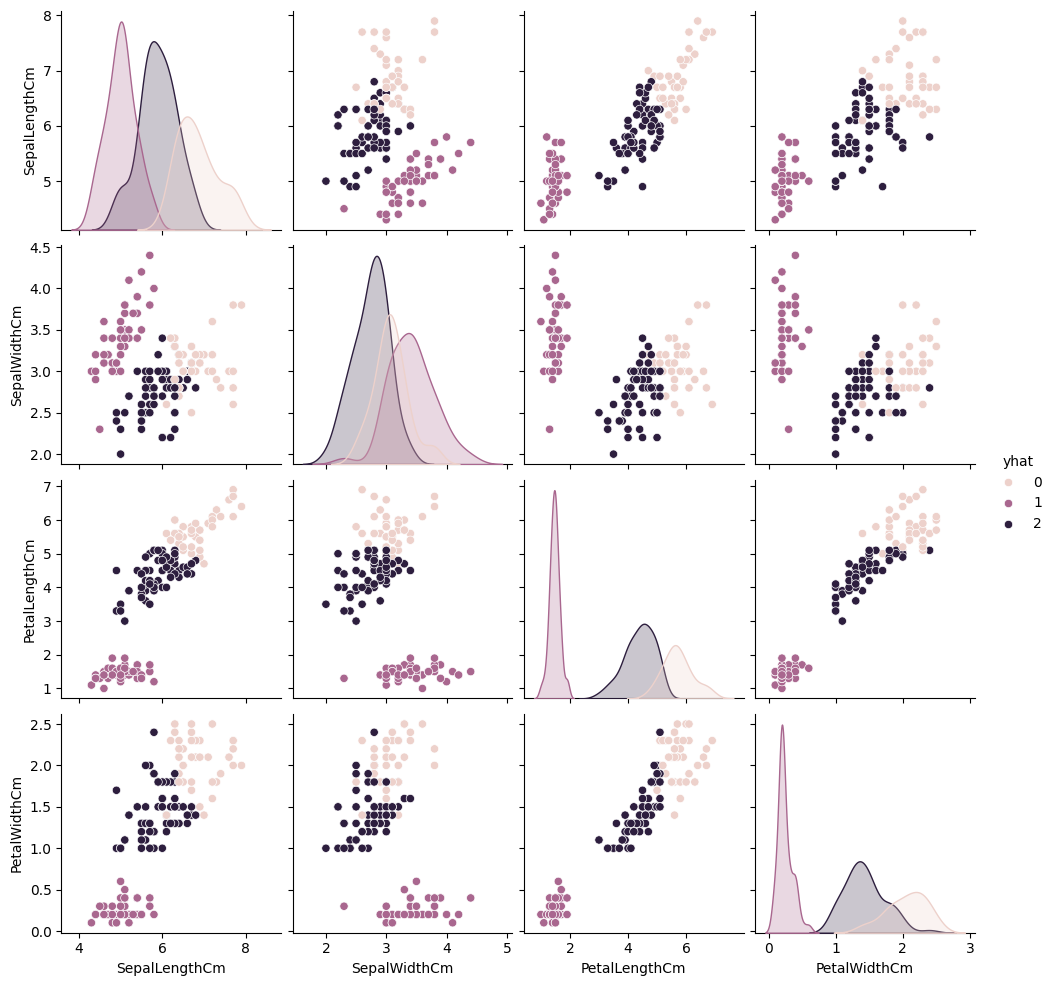

In [33]:
sb.pairplot(df, hue='yhat')

Comparando os dois conjuntos de gráficos acima, percebe-se que a dispersão resultante do agrupamento K-means é satisfatória quando comparada à classificação original do dataset na coluna species=target.